# Module 4 — Experiment Design: Hypotheses, Randomization & Guardrail Metrics

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Turning a product question into a testable hypothesis
> - Randomization unit: user vs. session vs. device vs. cluster, and why the choice changes both the analysis and the risk of contamination
> - Sample Ratio Mismatch (SRM) — what it is, why it invalidates a test, how to detect it
> - Primary metric, secondary metrics, guardrail metrics, and the Overall Evaluation Criterion (OEC) — designing what "success" means *before* looking at results
> - Pre-registration / analysis plans, and why deciding your test after seeing data is a trap
> - Practical randomization mechanics (hashing users into buckets, consistent bucketing across sessions)
>
> **Why it matters**
> Design mistakes here silently poison everything downstream — no amount of correct statistics rescues a badly randomized or badly scoped test. This is also where B2C experimentation platforms (Optimizely, GrowthBook, in-house systems) encode a lot of institutional best practice you won't have seen in B2B, where a "test" is often just a phased rollout to a handful of accounts.
>
> **Worked example**
> Designing a test for a new one-click checkout button: hypothesis is "reducing checkout friction increases completion rate without hurting order value." Randomization unit is the *user* (not session) so the same person doesn't see both variants across visits. Primary metric: checkout completion rate. Guardrails: revenue per user (make sure completion isn't coming from smaller carts) and refund rate (make sure faster checkout isn't causing mis-orders). The OEC combines these so a win on the primary metric that tanks a guardrail doesn't get shipped by accident.
>
> **Resources**
> - [Experiments at Airbnb](https://medium.com/airbnb-engineering/experiments-at-airbnb-e2db3abf39e7) — Jan Overgoor, Airbnb Tech Blog (~15 min, verified; Medium may prompt a free sign-in)
>
> **Exercise type:** design critique exercises — given a proposed test, find the design flaws (wrong randomization unit, missing guardrails, SRM risk) before ever touching data.
>
> **Interview angle:** "design an experiment for X" case questions — scored heavily on design rigor, not just stats.

## Lesson

### Turning a product question into a testable hypothesis

A vague idea ("let's improve checkout") isn't testable. A good hypothesis has three parts, in one sentence: **"If we [change], then [metric] will [move in this direction] because [mechanism]."** For example: *"If we reduce checkout from 3 steps to 1, then checkout completion rate will increase, because fewer steps means fewer chances for someone to abandon or get distracted."* The mechanism clause matters — it's what makes the hypothesis falsifiable and gives you something to reason about if the result comes back unexpected (Module 6).

### Randomization unit

The randomization unit is *what gets randomly assigned* — not every experiment should assign individual users. Four common choices:
- **User** — the default for most product changes (one user, one experience, consistently). Use this whenever the same person could plausibly encounter the feature more than once.
- **Session** — occasionally used for changes with no cross-visit memory (e.g. a one-time search-results ranking tweak), but risky for anything a returning user would notice — the same person could see *both* variants on different visits, which muddies what you're actually measuring.
- **Device** — for changes tied to hardware/app version rather than identity (e.g. a checkout flow change that's app-version-specific), or when you can't reliably identify a logged-out user across sessions.
- **Cluster** (a group of related units, e.g. all users in a city, or all members of a marketplace transaction) — needed whenever units within a cluster can influence each other (Module 6's interference problem). Randomizing individuals in a connected system contaminates both arms with each other's effects.

Picking the wrong unit doesn't just make the analysis awkward — it can quietly make the whole comparison invalid, because "control" stops meaning "didn't get the change" if control users are somehow still exposed to it.

### Sample Ratio Mismatch (SRM)

**SRM** is what happens when your traffic split comes out different from what you intended — you set up 50/50, but you actually observe something like 48.5% control / 51.5% treatment, by more than random chance would explain. SRM matters because it's usually a symptom of a bug in *how* users got assigned or logged (e.g. the treatment experience fails to load for some users and they silently fall back to a code path that doesn't get logged as "treatment," which is also correlated with exactly the kind of user experience you're trying to measure). **The consequence: if SRM is present, you cannot trust the experiment's result at all — not "trust it less," discard it entirely** — because the two groups are no longer comparable in the way randomization was supposed to guarantee, and you don't know which of your other numbers that same bug also quietly corrupted. Detecting it is a statistical test on the group *sizes* themselves, before you ever look at the outcome metric — Part 2 below builds this from scratch, reusing the exact chi-square machinery from Module 3.

### Primary, secondary, and guardrail metrics — and the OEC

- **Primary metric** — the one number that decides ship / no-ship. Pick exactly one, before the test starts.
- **Secondary metrics** — other numbers you'll look at for context or to understand *why* the primary metric moved, but that don't independently decide the outcome.
- **Guardrail metrics** — numbers that must NOT get worse, regardless of what the primary metric does. A win on the primary metric doesn't get shipped if a guardrail breaks.
- **OEC (Overall Evaluation Criterion)** — a single combined decision rule that folds the primary metric and guardrails together up front (e.g. "ship if primary metric improves AND no guardrail regresses by more than X"), so "is this a win" isn't a judgment call made *after* seeing convenient-looking numbers.

### Pre-registration

Pre-registration means writing down your hypothesis, primary metric, guardrails, and how long you'll run the test — **before** looking at any results. The trap it prevents: if you decide *after* seeing the data which metric counts as "the" result, or which segment looks interesting, you're implicitly running many hidden tests and cherry-picking the one that worked — the exact multiple-comparisons problem Module 5 covers in full. Pre-registration is the design-time discipline that prevents a Module 5 problem from ever having the chance to happen.

### Practical randomization mechanics: hashing

In practice, "randomly" assigning a user to a bucket isn't done by rolling dice each time they show up — it's done with a **hash function**: a deterministic function that turns an input (like a user ID) into what looks like a random-ish number, but always returns the *exact same* output for the *exact same* input. That determinism is the whole point: hash the same user ID today and hash it again next week, and they land in the same bucket both times — which is exactly what "consistent bucketing across sessions" requires. A good hash function's outputs are spread roughly uniformly across their range, which is what lets you turn "hash of user ID" into "roughly 50/50 bucket assignment" just by checking whether the hash falls in the top or bottom half of its range.

### Part 1 — Hashing users into buckets, from scratch

Building the actual mechanism: hash each user ID (combined with an experiment-specific "salt" — a fixed bit of text mixed into the hash input purely so the same user ID hashes differently for a different experiment) into a number, then use that number to assign a bucket. Checking two things: (1) does it produce a roughly even split, and (2) is it actually *consistent* — same user, same bucket, every time?

In [1]:
import hashlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=2024)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

In [2]:
def assign_bucket(user_id, experiment_salt, split=0.5):
    """Deterministically assigns a user to 'treatment' or 'control' for a given experiment."""
    key = f"{user_id}-{experiment_salt}".encode("utf-8")
    digest = hashlib.md5(key).hexdigest()          # deterministic: same input -> same output, always
    hash_int = int(digest, 16)                      # turn the hex string into a big integer
    fraction = (hash_int % 10_000) / 10_000          # squeeze it down to a number in [0, 1)
    return "treatment" if fraction < split else "control"

# 50,000 synthetic user IDs
user_ids = [f"user_{i}" for i in range(50_000)]

buckets = [assign_bucket(uid, experiment_salt="checkout_redesign_2026") for uid in user_ids]
bucket_counts = pd.Series(buckets).value_counts()
print("Bucket split:")
print(bucket_counts)
print(f"\nTreatment share: {bucket_counts['treatment'] / len(user_ids):.2%}")

Bucket split:
treatment    25021
control      24979
Name: count, dtype: int64

Treatment share: 50.04%


In [3]:
# Consistency check: hashing the SAME users again (e.g. simulating them returning next week)
# must give the IDENTICAL bucket every time -- that's the entire point of using a hash instead
# of a fresh random draw per visit.
buckets_again = [assign_bucket(uid, experiment_salt="checkout_redesign_2026") for uid in user_ids]
all_consistent = buckets == buckets_again
print(f"Every user got the same bucket both times: {all_consistent}")

# A DIFFERENT experiment (different salt) should look like an independent reshuffle for the
# same users -- otherwise users who are, say, always in "treatment" would end up correlated
# across every experiment the team ever runs, quietly breaking the independence assumption
# behind every test in Module 3.
buckets_other_experiment = [assign_bucket(uid, experiment_salt="pricing_test_2026") for uid in user_ids]
agreement_rate = np.mean([a == b for a, b in zip(buckets, buckets_other_experiment)])
print(f"Agreement with an unrelated experiment's assignment: {agreement_rate:.1%}  (expect ~50%, i.e. no correlation)")

Every user got the same bucket both times: True
Agreement with an unrelated experiment's assignment: 50.2%  (expect ~50%, i.e. no correlation)


**What this shows:** the split lands close to 50/50 (Part 2 formalizes "close enough"), every user's bucket is provably identical across two independent hash runs (the consistency the salted hash is *for*), and changing only the salt — same users, same underlying hash function — produces what looks like an unrelated 50/50 reshuffle, close to the 50% agreement rate you'd expect from two independent coin flips. That last point is a real, easy-to-miss design mistake in practice: reusing the same salt (or no salt at all) across different experiments means a user's assignment in one experiment silently predicts their assignment in another.

### Part 2 — Detecting Sample Ratio Mismatch, from scratch

This reuses the chi-square machinery from Module 3, pointed at a different question. But the real point here isn't "prove chi-square works" — it's trusted, published math, never in doubt. What this section is actually for: (1) building reading fluency for what a healthy SRM check looks like next to a broken one, using cases where we happen to know the ground truth so you can calibrate *before* you have to trust this read on a real experiment where you don't; and (2) showing that SRM detection has the same limits as any other hypothesis test — a big enough problem gets caught, a small enough one can hide, exactly the sample-size-dependent detection limit from Module 3's power section. Three scenarios: a healthy split, a bug big enough to catch, and a bug too small to catch.

In [4]:
def srm_test(observed_counts, expected_split=(0.5, 0.5)):
    """Chi-square goodness-of-fit test: does the observed group split match the intended one?"""
    total = sum(observed_counts)
    expected_counts = [total * p for p in expected_split]
    chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
    return chi2_stat, p_value

# Scenario 1: healthy split, straight from our hash function above
healthy_counts = [bucket_counts["control"], bucket_counts["treatment"]]
chi2_healthy, p_healthy = srm_test(healthy_counts)
print("Scenario 1 -- healthy bucketing (our hash function):")
print(f"  observed: control={healthy_counts[0]:,}, treatment={healthy_counts[1]:,}")
print(f"  chi2 = {chi2_healthy:.3f}, p-value = {p_healthy:.3f}")

# Scenario 2: a logging bug silently drops 4% of assigned treatment users before they're counted
true_control = 25_000
true_treatment = 25_000
logged_treatment = int(true_treatment * 0.96)  # 4% silently missing from the treatment log
buggy_counts = [true_control, logged_treatment]
chi2_buggy, p_buggy = srm_test(buggy_counts)
print("\nScenario 2 -- buggy bucketing (4% of treatment silently under-logged):")
print(f"  observed: control={buggy_counts[0]:,}, treatment={buggy_counts[1]:,}")
print(f"  chi2 = {chi2_buggy:.3f}, p-value = {p_buggy:.6f}")

# Scenario 3: a much SMALLER logging bug -- only 1% of treatment silently missing
# (same mechanism as Scenario 2, just a quarter the size)
missed_small = 250  # 1% of 25,000
small_bug_counts = [true_control, true_treatment - missed_small]
chi2_small, p_small = srm_test(small_bug_counts)
print("\nScenario 3 -- small bug (1% of treatment silently under-logged):")
print(f"  observed: control={small_bug_counts[0]:,}, treatment={small_bug_counts[1]:,}")
print(f"  chi2 = {chi2_small:.3f}, p-value = {p_small:.4f}")

Scenario 1 -- healthy bucketing (our hash function):
  observed: control=24,979, treatment=25,021
  chi2 = 0.035, p-value = 0.851

Scenario 2 -- buggy bucketing (4% of treatment silently under-logged):
  observed: control=25,000, treatment=24,000
  chi2 = 20.408, p-value = 0.000006

Scenario 3 -- small bug (1% of treatment silently under-logged):
  observed: control=25,000, treatment=24,750
  chi2 = 1.256, p-value = 0.2624


**Showing the two steps by hand, for Scenario 2 (the caught bug):** observed control = 25,000, treatment = 24,000; expected (50/50 of 49,000 total) = 24,500 each.

**Step 1 — the chi-square statistic**, plain arithmetic:
```
control term:   (25,000 - 24,500)^2 / 24,500 = 10.2041
treatment term: (24,000 - 24,500)^2 / 24,500 = 10.2041
chi2 = 10.2041 + 10.2041 = 20.4082
```

**Step 2 — converting that number into a p-value**, using the chi-square distribution's CDF (1 degree of freedom, since there are 2 categories) — this part isn't ordinary arithmetic, same reason `norm.cdf` wasn't hand-derived in Module 3:
```
p = 1 - chi2_cdf(20.4082, df=1) = 0.00000626
```

Matches the `chi2 = 20.408, p-value = 0.000006` printed above exactly — this is the actual mechanics behind that one line of code, not a black box.

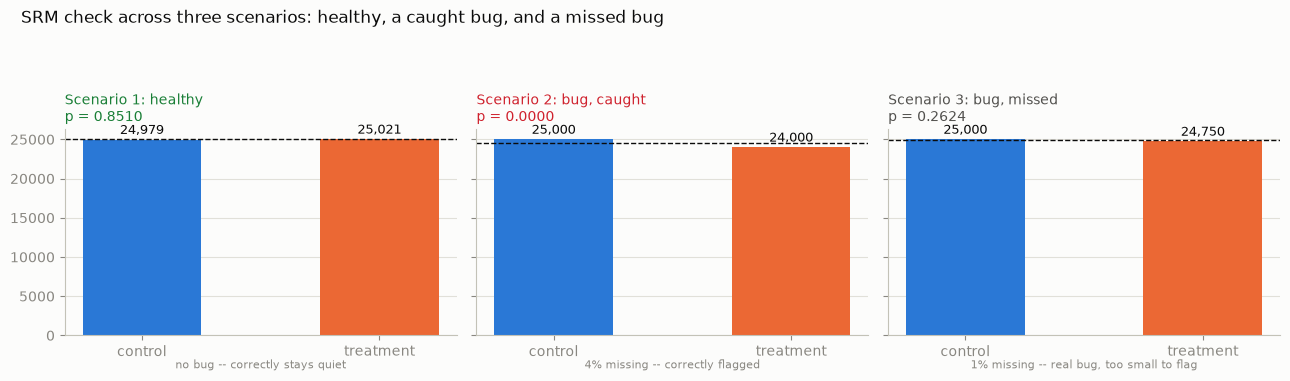

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), facecolor="#fcfcfb", sharey=True)
scenarios = [
    ("Scenario 1: healthy", healthy_counts, p_healthy, GOOD, "no bug -- correctly stays quiet"),
    ("Scenario 2: bug, caught", buggy_counts, p_buggy, BAD, "4% missing -- correctly flagged"),
    ("Scenario 3: bug, missed", small_bug_counts, p_small, INK_SECONDARY, "1% missing -- real bug, too small to flag"),
]

for ax, (title, counts, p_val, color, subtitle) in zip(axes, scenarios):
    ax.set_facecolor("#fcfcfb")
    expected = sum(counts) / 2
    bars = ax.bar(["control", "treatment"], counts, color=[BLUE, ORANGE], width=0.5)
    ax.axhline(expected, color=INK, linewidth=1, linestyle="--")
    for b in bars:
        ax.annotate(f"{b.get_height():,.0f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, color=INK)
    ax.set_title(f"{title}\np = {p_val:.4f}", color=color, fontsize=10, loc="left")
    ax.text(0.5, -0.16, subtitle, transform=ax.transAxes, ha="center", fontsize=8, color=INK_MUTED)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle("SRM check across three scenarios: healthy, a caught bug, and a missed bug", color=INK, fontsize=12, x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.subplots_adjust(bottom=0.24)
plt.show()

**What this shows:** three scenarios, same test, three different pieces of information.

- **Scenario 1 (healthy):** no real problem, and the test correctly stays quiet (p = 0.851). A true negative.
- **Scenario 2 (bug, caught):** a real 4% miss-logging problem, and the test correctly flags it (p = 0.000006). A true positive.
- **Scenario 3 (bug, missed):** a real problem too -- just a quarter the size (1% instead of 4%) -- and the test does NOT flag it (p = 0.2624). From the test's output alone, this looks identical to Scenario 1: both say "not significant." But we know, because we built the simulation, that a real assignment problem exists here; it's just too small relative to this sample size for the test to reliably separate from ordinary random noise.

That third case is the actual lesson, not a footnote: **an SRM check, like any hypothesis test, has a detection floor set by your sample size** -- exactly Module 3's power logic, just applied to the group sizes instead of an outcome metric. A clean SRM p-value tells you "no problem big enough to detect," not "no problem." In practice, that's why SRM checks are paired with engineering-side monitoring (logging/assignment audits), not treated as a complete substitute for one.

### Part 3 — Design critique: three proposed tests, worked

The exercise this module promises: given a proposed test, find the design flaws before ever touching data. Three briefs below, each checked against six dimensions from the lesson — hypothesis, randomization unit, primary metric, guardrails, pre-registration, and SRM planning.

**Brief A — One-click checkout** *(this module's own worked example)*

> "We're replacing the 3-step checkout with a single-page checkout. Hypothesis: if we reduce checkout to one page, completion rate will increase, because fewer steps means fewer chances to abandon. We'll randomize by user ID so a given customer always sees the same version. Primary metric: checkout completion rate. Guardrails: revenue per user, refund rate. We'll pre-register a 2-week run and won't make a ship decision before then. We'll check for SRM before looking at results."

| Dimension | Verdict | Why |
|---|---|---|
| Hypothesis | <span style="color:#1a7f37"><b>Sound</b></span> | Full "if/then/because" form — falsifiable, gives a mechanism to reason about if results surprise |
| Randomization unit | <span style="color:#1a7f37"><b>Sound</b></span> | User-level, correctly avoiding cross-visit contamination |
| Primary metric | <span style="color:#1a7f37"><b>Sound</b></span> | One clearly named metric |
| Guardrails | <span style="color:#1a7f37"><b>Sound</b></span> | Two specific, relevant guardrails named up front |
| Pre-registration | <span style="color:#1a7f37"><b>Sound</b></span> | Duration and no-early-peeking committed before the test starts |
| SRM plan | <span style="color:#1a7f37"><b>Sound</b></span> | Explicitly planned as a pre-check |

This is what a fully sound design looks like — every later brief gets judged against this bar.

**Brief B — Homepage redesign**

> "We're testing a new homepage layout. If it's better, engagement should go up. We'll randomize by session so we can start collecting data immediately without needing to identify users. We'll watch daily dashboards and ship as soon as we see a significant lift."

| Dimension | Verdict | Why |
|---|---|---|
| Hypothesis | <span style="color:#cf222e"><b>Flawed</b></span> | No mechanism ("if it's better" isn't a because) and "engagement" is undefined — engagement in what, measured how? |
| Randomization unit | <span style="color:#cf222e"><b>Flawed</b></span> | Session-level for a homepage a returning user will hit repeatedly — the same person can land in both arms across visits, contaminating the comparison |
| Primary metric | <span style="color:#cf222e"><b>Flawed</b></span> | "Engagement" was never made concrete — clicks? time on page? return visits? Each implies a different test |
| Guardrails | <span style="color:#cf222e"><b>Flawed</b></span> | None named at all |
| Pre-registration | <span style="color:#cf222e"><b>Flawed</b></span> | "Ship as soon as we see a significant lift" is exactly the peeking problem Module 5 covers — no fixed duration, no commitment to a single look |
| SRM plan | <span style="color:#cf222e"><b>Flawed</b></span> | Not mentioned |

This brief has a flaw in every dimension — a useful extreme case, but real proposals rarely look this broken across the board. Brief C is closer to what you'll actually encounter.

**Brief C — Referral bonus test**

> "We're testing a higher referral bonus ($20 instead of $10). Hypothesis: if we raise the bonus, referral signups will increase, because a bigger reward is a stronger incentive. We'll randomize by user ID. We'll track referral signups, activation rate of referred users, revenue per referring user, and overall app engagement, and pick whichever looks most convincing when the test wraps up. We'll run it for 3 weeks."

| Dimension | Verdict | Why |
|---|---|---|
| Hypothesis | <span style="color:#1a7f37"><b>Sound</b></span> | Clear if/then/because |
| Randomization unit | <span style="color:#1a7f37"><b>Sound</b></span> | User-level, appropriate here |
| Primary metric | <span style="color:#cf222e"><b>Flawed</b></span> | Four metrics listed with no primary designated — "whichever looks most convincing" decided *after* the fact is precisely the cherry-picking pre-registration exists to prevent |
| Guardrails | <span style="color:#cf222e"><b>Flawed</b></span> | None of the four metrics is framed as a must-not-regress guardrail (revenue per referring user is a natural guardrail candidate here — a bigger bonus could increase signups while making each referral less profitable) |
| Pre-registration | <span style="color:#1a7f37"><b>Sound</b></span> | Duration is fixed (3 weeks) |
| SRM plan | <span style="color:#cf222e"><b>Flawed</b></span> | Not mentioned |

This is the more realistic failure mode: a design that gets the fundamentals right (hypothesis, randomization unit, duration) but skips the less obvious discipline (naming one primary metric and its guardrails up front, planning an SRM check) — exactly the kind of gap that's easy to miss without a checklist like this one.

**If we were fixing this design**, here's how the four metrics should probably split: **primary = referral signups** (it's the direct thing the hypothesis is about). **Guardrails = revenue per referring user** (bonus cost vs. value) **and activation rate of referred users** — worth calling out specifically, because it's the same leading-vs-lagging risk from Module 2's worked example, just wearing a referral-program costume: a bigger bonus could pull in more signups (the proxy moving up) from lower-intent people who never activate (the truer signal moving down). **Neither = overall app engagement** — too indirect and noisy to reliably attribute to a referral bonus change; fine to glance at as context, but not sound enough to gate a ship decision as either the primary metric or a guardrail.

## Key takeaways

- A hypothesis needs a mechanism ("because..."), not just a direction — that's what makes it falsifiable and useful when results surprise you
- The randomization unit has to match how users actually experience the product — get it wrong and "control" stops meaning what you think it means
- SRM is a check on the experiment's plumbing, not its outcome — run it before trusting any result, using the same chi-square tool from Module 3 pointed at a different question
- Name exactly one primary metric and its guardrails *before* the test starts — "we'll pick whichever metric looks best" is cherry-picking with extra steps
- A hash-based, salted assignment function is what makes "consistent bucketing" and "independent experiments" both possible at once — and reusing a salt across experiments is a real, common mistake

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*